<a href="https://colab.research.google.com/github/Sai-light-18/MLopsDVCSaiJyothi/blob/main/Fraudemail_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving spam_ham_dataset.csv to spam_ham_dataset (1).csv


In [ ]:
import pandas as pd
import io

data = pd.read_csv(io.BytesIO(uploaded['spam_ham_dataset (1).csv']))
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [ ]:
data.shape

(5171, 4)

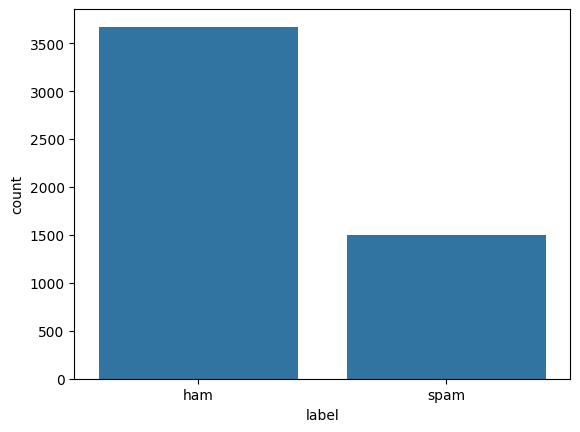

In [ ]:
sns.countplot(x='label', data=data)
plt.show()

<Axes: xlabel='label', ylabel='count'>

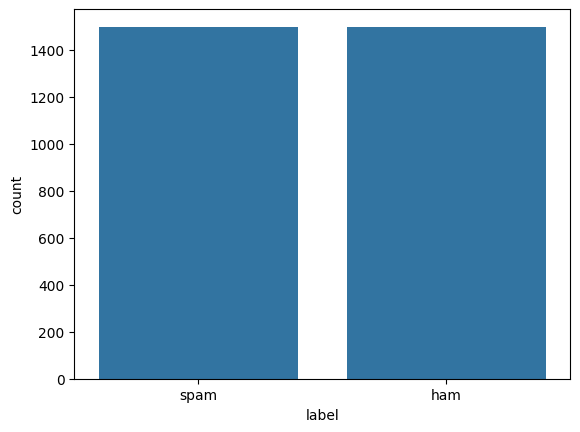

In [ ]:
ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']



ham_msg_bal = ham_msg.sample(n = len(spam_msg), random_state = 42)


bal_data = pd.concat([spam_msg, ham_msg_bal], axis = 0)
bal_data.head()


sns.countplot(x = 'label', data = bal_data)


In [ ]:
bal_data['text'] = bal_data['text'].str.replace('Subject', '')
bal_data.head()


,Unnamed: 0,label,text,label_num
3,4685,spam,": photoshop , windows , office . cheap . main ...",1
7,4185,spam,: looking for medication ? we ` re the best so...,1
10,4922,spam,: vocable % rnd - word asceticism\r\nvcsc - br...,1
11,3799,spam,: report 01405 !\r\nwffur attion brom est inst...,1
13,3948,spam,: vic . odin n ^ ow\r\nberne hotbox carnal bri...,1


In [ ]:
punctuations_list = string.punctuation
def remove_punctuations(text):
  temp = str.maketrans('','', punctuations_list)
  return text.translate(temp)
bal_data['text'] = bal_data['text'].apply(lambda x:remove_punctuations(x))
bal_data.head()

,Unnamed: 0,label,text,label_num
3,4685,spam,photoshop windows office cheap main trend...,1
7,4185,spam,looking for medication we re the best sourc...,1
10,4922,spam,vocable rnd word asceticism\r\nvcsc brand ...,1
11,3799,spam,report 01405 \r\nwffur attion brom est inst s...,1
13,3948,spam,vic odin n ow\r\nberne hotbox carnal bride ...,1


In [ ]:
def remove_stopwords(text):
  stop_words = stopwords.words('english')

  imp_words = []
  for word in  str(text).split():
    word = word.lower()

    if word not in stop_words:
      imp_words.append(word)
  output = " ".join(imp_words)
  return output

bal_data['text'] = bal_data['text'].apply(lambda text: remove_stopwords(text))
bal_data.head()

,Unnamed: 0,label,text,label_num
3,4685,spam,photoshop windows office cheap main trending a...,1
7,4185,spam,looking medication best source difficult make ...,1
10,4922,spam,vocable rnd word asceticism vcsc brand new sto...,1
11,3799,spam,report 01405 wffur attion brom est inst siupie...,1
13,3948,spam,vic odin n ow berne hotbox carnal bride cutwor...,1


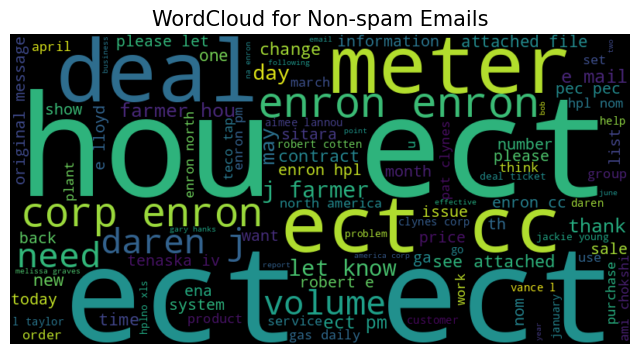

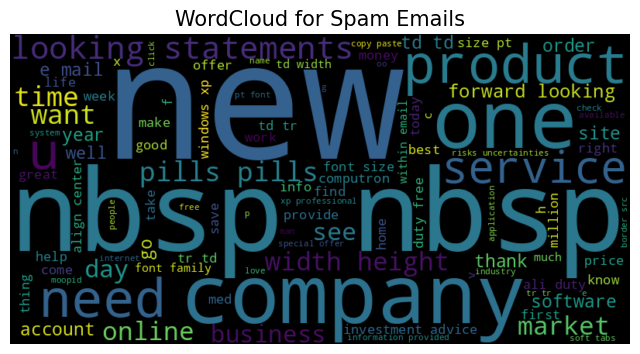

In [ ]:
def plot_word_cloud(data, typ):
  email_corpus = " ".join(data['text'])
  wc = WordCloud(background_color = 'black' , max_words = 100, width = 800, height = 400).generate(email_corpus)
  plt.figure(figsize = (8, 18))
  plt.imshow(wc, interpolation = 'bilinear')
  plt.title(f'WordCloud for {typ} Emails', fontsize = 15)
  plt.axis('off')
  plt.show()
plot_word_cloud(bal_data[bal_data['label'] == 'ham'], typ = 'Non-spam')
plot_word_cloud(bal_data[bal_data['label'] == 'spam'],typ ='Spam')



In [ ]:
train_X, test_X, train_Y, test_Y = train_test_split(
    bal_data['text'], bal_data['label'], test_size=0.2, random_state=42
)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100  # Maximum sequence length
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32, input_length=max_len),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_sequences, train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.4879 - loss: 0.6923 - val_accuracy: 0.5950 - val_loss: 0.6823 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.6422 - loss: 0.6264 - val_accuracy: 0.6783 - val_loss: 0.5896 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.7339 - loss: 0.4976 - val_accuracy: 0.9550 - val_loss: 0.2435 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9512 - loss: 0.2101 - val_accuracy: 0.9083 - val_loss: 0.2920 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.9579 - loss: 0.1548 - val_accuracy: 0.9567 - val_loss: 0.1658 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.9787 - loss: 0.0952 - val_accuracy: 0.9583 - val_loss: 0.1690 - learning_rate: 0.0010
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.9829 - loss: 0.0807 - val_ac

In [ ]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9617 - loss: 0.1601
Test Loss : 0.16006459295749664
Test Accuracy : 0.9616666436195374


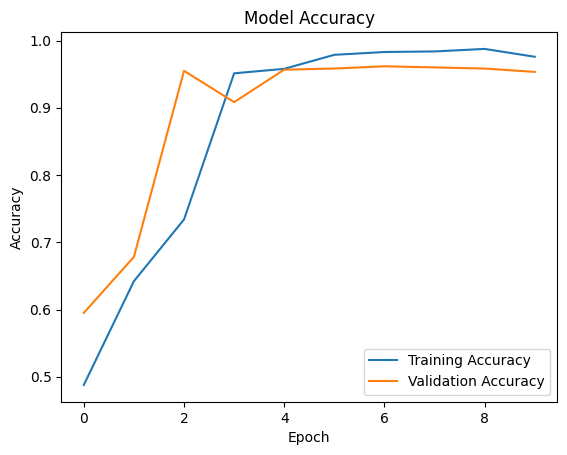

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()